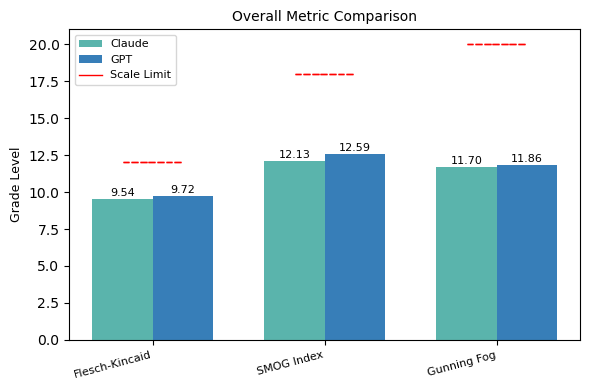

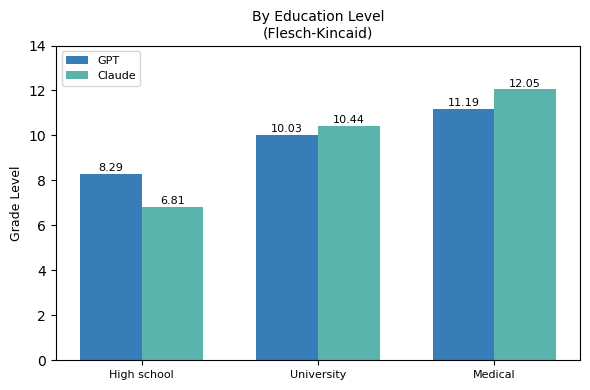

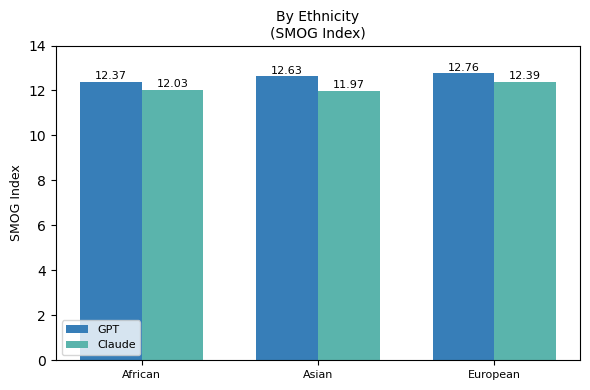

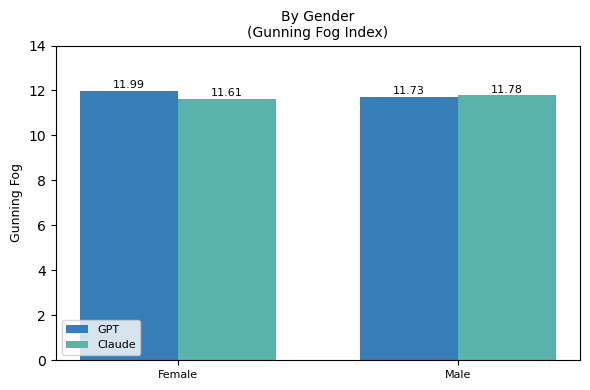

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Common settings
gpt_color = '#377eb8'
claude_color = '#5ab4ac'
width = 0.35

# -------------------------------
# Plot 1: Overall Metric Comparison (with labels)
# -------------------------------
metrics = ["Flesch-Kincaid", "SMOG Index", "Gunning Fog"]
gpt_all = [9.72, 12.59, 11.86]
claude_all = [9.54, 12.13, 11.70]
scale_limits = [12, 18, 20]
x = np.arange(len(metrics))

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, claude_all, width, label='Claude', color=claude_color)
bars2 = ax.bar(x + width/2, gpt_all, width, label='GPT', color=gpt_color)

ax.set_title('Overall Metric Comparison', fontsize=10)
ax.set_ylabel('Grade Level', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15, ha='right', fontsize=8)

# Cap lines
def draw_horizontal_stripes(x_center, y_level, total_width, n_stripes=7, stripe_len=0.04):
    spacing = total_width / n_stripes
    start_x = x_center - total_width / 2
    for i in range(n_stripes):
        x_start = start_x + i * spacing
        x_end = x_start + stripe_len
        ax.hlines(y=y_level, xmin=x_start, xmax=x_end, color='red', linewidth=1)

for i, limit in enumerate(scale_limits):
    draw_horizontal_stripes(x[i] - width/2 + width/2, limit, width)
    draw_horizontal_stripes(x[i] + width/2 - width/2, limit, width)

# Add number labels
for bars in [bars1, bars2]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 2), textcoords="offset points",
                    ha='center', fontsize=8)

# Legend with scale cap line
scale_line = Line2D([0], [0], color='red', linewidth=1, label='Scale Limit')
ax.legend(handles=[bars1, bars2, scale_line], fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()



# -------------------------------------
# Plot 2: Education Level
# -------------------------------------
education_levels = ["High school", "University", "Medical"]
gpt_scores_edu = [8.29, 10.03, 11.19]
claude_scores_edu = [6.81, 10.44, 12.05]
x = np.arange(len(education_levels))

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, gpt_scores_edu, width, label='GPT', color=gpt_color)
bars2 = ax.bar(x + width/2, claude_scores_edu, width, label='Claude', color=claude_color)

ax.set_title('By Education Level\n(Flesch-Kincaid)', fontsize=10)
ax.set_ylabel('Grade Level', fontsize=9)
ax.set_ylim(0, 14)
ax.set_xticks(x)
ax.set_xticklabels(education_levels, fontsize=8)
ax.legend(fontsize=8)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    textcoords="offset points", xytext=(0, 2), ha='center', fontsize=8)

plt.tight_layout()
plt.show()


# -------------------------------------
# Plot 3: Ethnicity
# -------------------------------------
ethnicities = ["European", "African", "Asian"]
gpt_scores_eth = [12.76, 12.37, 12.63]
claude_scores_eth = [12.39, 12.03, 11.97]
avg_eth = [(g + c) / 2 for g, c in zip(gpt_scores_eth, claude_scores_eth)]
sorted_idx = np.argsort(avg_eth)
eth_sorted = [ethnicities[i] for i in sorted_idx]
gpt_sorted = [gpt_scores_eth[i] for i in sorted_idx]
claude_sorted = [claude_scores_eth[i] for i in sorted_idx]
x = np.arange(len(eth_sorted))

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, gpt_sorted, width, label='GPT', color=gpt_color)
bars2 = ax.bar(x + width/2, claude_sorted, width, label='Claude', color=claude_color)

ax.set_title('By Ethnicity\n(SMOG Index)', fontsize=10)
ax.set_ylabel('SMOG Index', fontsize=9)
ax.set_ylim(0, 14)
ax.set_xticks(x)
ax.set_xticklabels(eth_sorted, fontsize=8)
ax.legend(fontsize=8)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    textcoords="offset points", xytext=(0, 2), ha='center', fontsize=8)

plt.tight_layout()
plt.show()


# -------------------------------------
# Plot 4: Gender
# -------------------------------------
genders = ["Female", "Male"]
gpt_scores_gen = [11.99, 11.73]
claude_scores_gen = [11.61, 11.78]
x = np.arange(len(genders))

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, gpt_scores_gen, width, label='GPT', color=gpt_color)
bars2 = ax.bar(x + width/2, claude_scores_gen, width, label='Claude', color=claude_color)

ax.set_title('By Gender\n(Gunning Fog Index)', fontsize=10)
ax.set_ylabel('Gunning Fog', fontsize=9)
ax.set_ylim(0, 14)
ax.set_xticks(x)
ax.set_xticklabels(genders, fontsize=8)
ax.legend(fontsize=8, loc='lower left')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    textcoords="offset points", xytext=(0, 2), ha='center', fontsize=8)

plt.tight_layout()
plt.show()
